# 🤖 Phase 2 — Model Training & SHAP Explainability

**Project:** AI Resume–Job Description Semantic Matcher with Explainability  
**Run after:** `01_eda_preprocessing.ipynb`  

---

## What this notebook does
1. **Cell 1–2** — Install dependencies & imports  
2. **Cell 3** — Load splits + config from `outputs/`  
3. **Cell 4** — Train XGBoost Regression (predicts match score 0–1)  
4. **Cell 5** — Train XGBoost Classifier (Reject / Maybe / Shortlist)  
5. **Cell 6** — Evaluate both models (RMSE, F1, confusion matrix)  
6. **Cell 7** — SHAP explainability (global + per-prediction)  
7. **Cell 8** — Save models + results to `outputs/`  

---
⚠️ **Before running:** Make sure `outputs/` folder from Notebook 1 is uploaded to your Google Drive.

## Cell 1 — Install dependencies
> Run once. Restart runtime after this cell.

In [1]:
# ── Install packages ───────────────────────────────────────────────────────
!pip install -q xgboost shap scikit-learn pandas numpy matplotlib seaborn
print("✅ Done. Restart runtime now (Runtime → Restart), then run from Cell 2.")

✅ Done. Restart runtime now (Runtime → Restart), then run from Cell 2.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, pickle, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, f1_score
)
from sklearn.preprocessing import LabelEncoder
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# No Drive needed — files uploaded directly to Colab
OUTPUTS_DIR = '/content'

os.makedirs(f'{OUTPUTS_DIR}/plots', exist_ok=True)
os.makedirs(f'{OUTPUTS_DIR}/models', exist_ok=True)
print(f'✅ Imports done. Reading from: {OUTPUTS_DIR}')

✅ Imports done. Reading from: /content


## Cell 2 — Imports & Mount Google Drive

## Cell 3 — Load splits & config

In [3]:
# ── Load config (tells us which columns are features) ─────────────────────
with open(f'{OUTPUTS_DIR}/preprocessing_config.json') as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# ── Load splits ────────────────────────────────────────────────────────────
df_train = pd.read_csv(f'{OUTPUTS_DIR}/train.csv')
df_val   = pd.read_csv(f'{OUTPUTS_DIR}/val.csv')
df_test  = pd.read_csv(f'{OUTPUTS_DIR}/test.csv')

print(f'\nTrain: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'\nLabel distribution (train):')
print(df_train['label'].value_counts())

# ── Prepare X and y ────────────────────────────────────────────────────────
X_train = df_train[FEATURE_COLS].fillna(0)
X_val   = df_val[FEATURE_COLS].fillna(0)
X_test  = df_test[FEATURE_COLS].fillna(0)

# Regression target
y_train_reg = df_train['matched_score']
y_val_reg   = df_val['matched_score']
y_test_reg  = df_test['matched_score']

# Classification target (encode: Reject=0, Maybe=1, Shortlist=2)
le = LabelEncoder()
le.classes_ = np.array(['Maybe', 'Reject', 'Shortlist'])  # alphabetical
y_train_cls = le.transform(df_train['label'])
y_val_cls   = le.transform(df_val['label'])
y_test_cls  = le.transform(df_test['label'])

print(f'\n✅ Data ready. X shape: {X_train.shape}')

Features (10): ['feat_skill_overlap', 'feat_resume_skill_count', 'feat_jd_skill_count', 'feat_missing_skill_count', 'feat_edu_match', 'feat_edu_level_resume', 'feat_edu_level_jd', 'feat_exp_years_required', 'feat_resume_text_len', 'feat_sbert_similarity']

Train: 5,428 | Val: 1,160 | Test: 1,163

Label distribution (train):
label
Maybe        2408
Shortlist    1890
Reject       1130
Name: count, dtype: int64

✅ Data ready. X shape: (5428, 10)


## Cell 4 — Train XGBoost Regression model
> Predicts a continuous match score between 0 and 1

[0]	validation_0-rmse:0.16412
[50]	validation_0-rmse:0.12682
[100]	validation_0-rmse:0.12251
[150]	validation_0-rmse:0.12104
[200]	validation_0-rmse:0.12048
[250]	validation_0-rmse:0.12014
[276]	validation_0-rmse:0.12025

── Regression (Validation) ───────────────
RMSE : 0.1201  (lower is better, max error = 1.0)
MAE  : 0.0933
R²   : 0.4776  (closer to 1.0 is better)


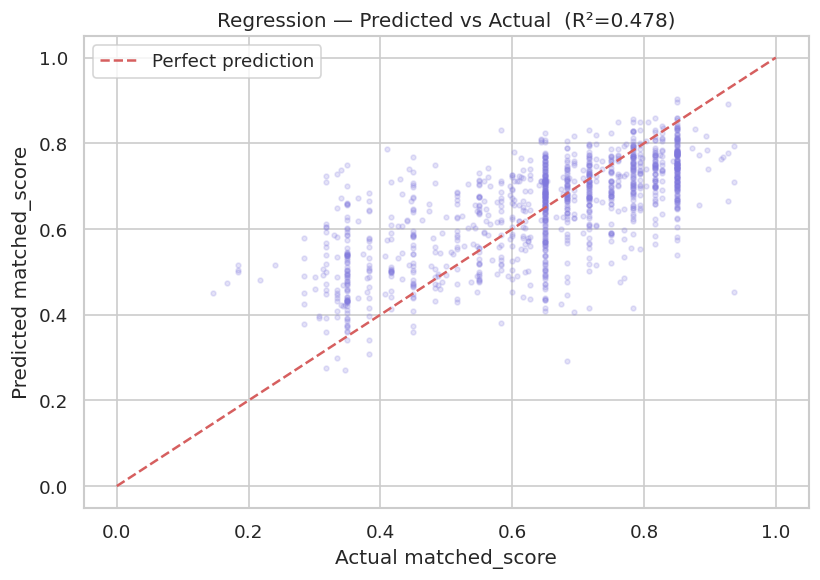

Saved: reg_pred_vs_actual.png


In [5]:
# ── XGBoost Regressor ──────────────────────────────────────────────────────
reg_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=20,
    verbosity=0
)

reg_model.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=50
)

# ── Validation metrics ─────────────────────────────────────────────────────
val_preds_reg = reg_model.predict(X_val)
val_preds_reg = np.clip(val_preds_reg, 0, 1)  # keep in [0,1]

rmse = mean_squared_error(y_val_reg, val_preds_reg) ** 0.5
mae  = mean_absolute_error(y_val_reg, val_preds_reg)
r2   = r2_score(y_val_reg, val_preds_reg)

print(f'\n── Regression (Validation) ───────────────')
print(f'RMSE : {rmse:.4f}  (lower is better, max error = 1.0)')
print(f'MAE  : {mae:.4f}')
print(f'R²   : {r2:.4f}  (closer to 1.0 is better)')

# ── Plot: predicted vs actual ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_val_reg, val_preds_reg, alpha=0.2, s=8, color='#7F77DD')
ax.plot([0,1],[0,1], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual matched_score')
ax.set_ylabel('Predicted matched_score')
ax.set_title(f'Regression — Predicted vs Actual  (R²={r2:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/plots/reg_pred_vs_actual.png', bbox_inches='tight')
plt.show()
print('Saved: reg_pred_vs_actual.png')

## Cell 5 — Train XGBoost Classifier
> Classifies resume as Reject / Maybe / Shortlist

[0]	validation_0-mlogloss:1.04342
[50]	validation_0-mlogloss:0.83771
[100]	validation_0-mlogloss:0.80530
[150]	validation_0-mlogloss:0.79421
[200]	validation_0-mlogloss:0.78984
[250]	validation_0-mlogloss:0.78825
[251]	validation_0-mlogloss:0.78814
── Classification Report (Validation) ───────────
              precision    recall  f1-score   support

       Maybe       0.61      0.66      0.63       514
      Reject       0.65      0.57      0.61       242
   Shortlist       0.66      0.64      0.65       404

    accuracy                           0.63      1160
   macro avg       0.64      0.62      0.63      1160
weighted avg       0.63      0.63      0.63      1160



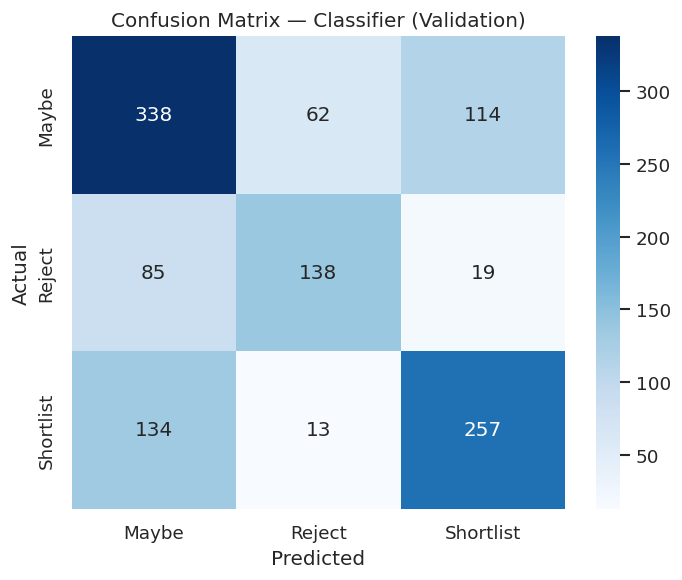

Saved: cls_confusion_matrix.png


In [6]:
# ── XGBoost Classifier ─────────────────────────────────────────────────────
cls_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

cls_model.fit(
    X_train, y_train_cls,
    eval_set=[(X_val, y_val_cls)],
    verbose=50
)

val_preds_cls = cls_model.predict(X_val)

print('── Classification Report (Validation) ───────────')
print(classification_report(y_val_cls, val_preds_cls,
                             target_names=le.classes_))

# ── Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_val_cls, val_preds_cls)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Classifier (Validation)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/plots/cls_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: cls_confusion_matrix.png')

## Cell 6 — Final evaluation on TEST set
> Use test set only once — these are your final reported numbers

In [8]:
# ── Test set evaluation ────────────────────────────────────────────────────
test_preds_reg = np.clip(reg_model.predict(X_test), 0, 1)
test_preds_cls = cls_model.predict(X_test)

test_rmse = mean_squared_error(y_test_reg, test_preds_reg) ** 0.5
test_mae  = mean_absolute_error(y_test_reg, test_preds_reg)
test_r2   = r2_score(y_test_reg, test_preds_reg)
test_f1   = f1_score(y_test_cls, test_preds_cls, average='weighted')

print('=' * 50)
print('FINAL TEST SET RESULTS (report these in your paper)')
print('=' * 50)
print(f'Regression  RMSE : {test_rmse:.4f}')
print(f'Regression  MAE  : {test_mae:.4f}')
print(f'Regression  R²   : {test_r2:.4f}')
print(f'Classifier  F1   : {test_f1:.4f} (weighted)')
print()
print(classification_report(y_test_cls, test_preds_cls,
                             target_names=le.classes_))

# Save metrics to JSON for later use in demo
metrics = {
    'test_rmse': round(float(test_rmse), 4),
    'test_mae':  round(float(test_mae), 4),
    'test_r2':   round(float(test_r2), 4),
    'test_f1_weighted': round(float(test_f1), 4)
}
with open(f'{OUTPUTS_DIR}/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('✅ Saved: model_metrics.json')

FINAL TEST SET RESULTS (report these in your paper)
Regression  RMSE : 0.1228
Regression  MAE  : 0.0941
Regression  R²   : 0.4692
Classifier  F1   : 0.6256 (weighted)

              precision    recall  f1-score   support

       Maybe       0.60      0.66      0.62       516
      Reject       0.59      0.47      0.52       242
   Shortlist       0.69      0.69      0.69       405

    accuracy                           0.63      1163
   macro avg       0.63      0.60      0.61      1163
weighted avg       0.63      0.63      0.63      1163

✅ Saved: model_metrics.json


## Cell 7 — SHAP Explainability
> This is what makes your project stand out — explains WHY each score was given

Computing SHAP values... (takes ~1 min)


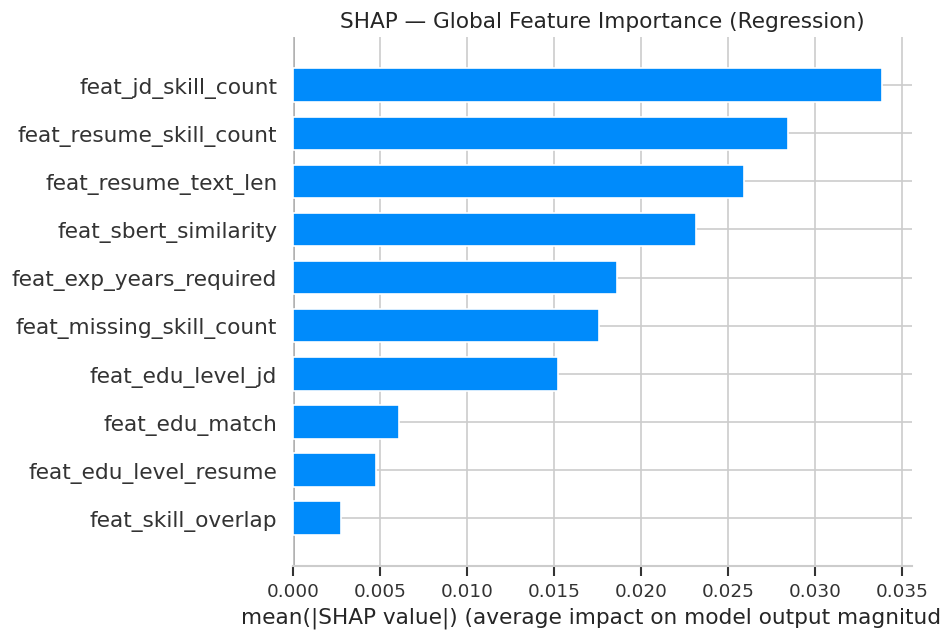

Saved: shap_global_bar.png


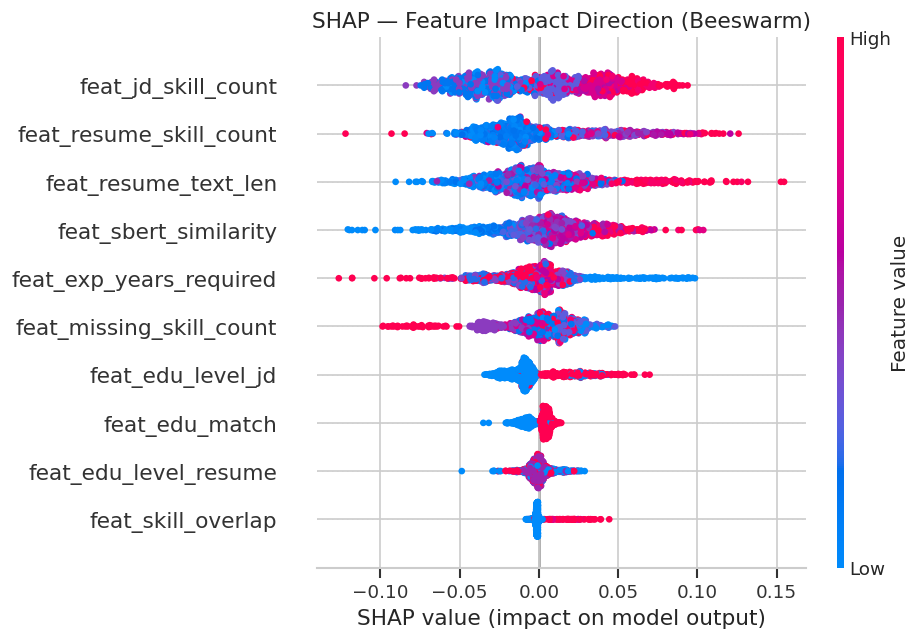

Saved: shap_beeswarm.png


In [9]:
# ── SHAP Global Feature Importance ────────────────────────────────────────
print('Computing SHAP values... (takes ~1 min)')
explainer = shap.TreeExplainer(reg_model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Global bar chart — which features matter most overall
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  feature_names=FEATURE_COLS, show=False)
plt.title('SHAP — Global Feature Importance (Regression)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/plots/shap_global_bar.png', bbox_inches='tight')
plt.show()
print('Saved: shap_global_bar.png')

# Plot 2: Beeswarm — shows direction of each feature's impact
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURE_COLS, show=False)
plt.title('SHAP — Feature Impact Direction (Beeswarm)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/plots/shap_beeswarm.png', bbox_inches='tight')
plt.show()
print('Saved: shap_beeswarm.png')

## Cell 8 — SHAP: Per-prediction explanation (single resume)
> This is what Agent 5 will use at inference time to explain each result

Sample resume — Predicted score: 0.737 → Shortlist
Actual score: 0.850



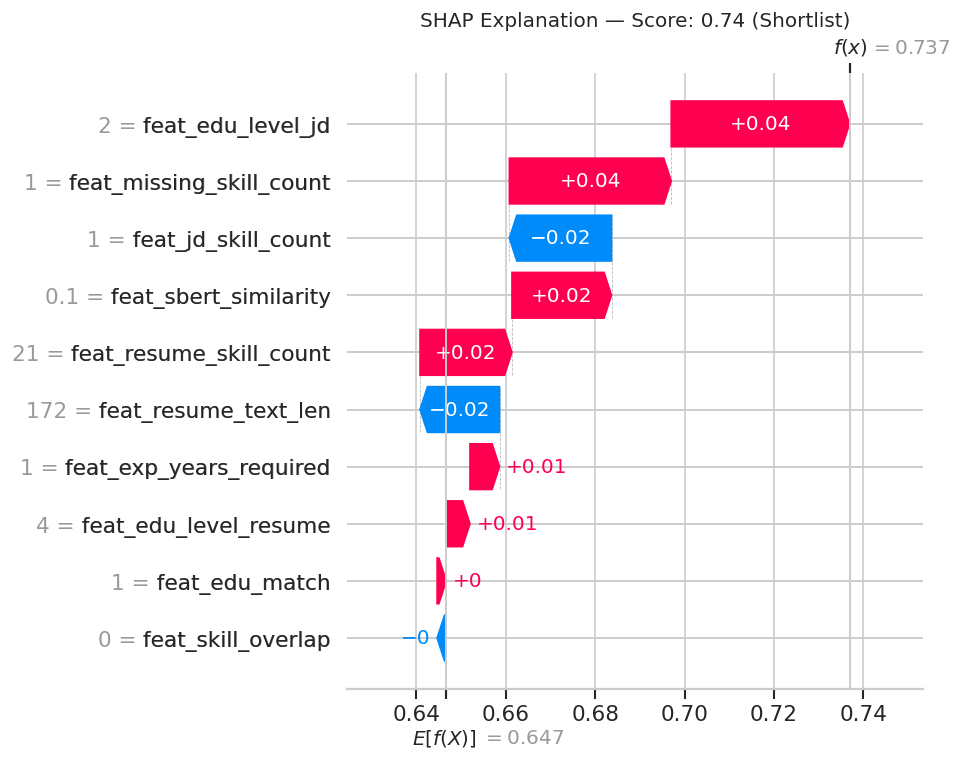

Saved: shap_single_waterfall.png
── Why this resume scored the way it did ──────────
Top factors HELPING the score:
  ✅ edu_level_jd                   impact: +0.0399
  ✅ missing_skill_count            impact: +0.0362
  ✅ sbert_similarity               impact: +0.0223

Top factors HURTING the score:
  ❌ jd_skill_count                 impact: -0.0229
  ❌ resume_text_len                impact: -0.0178
  ❌ skill_overlap                  impact: -0.0019


In [10]:
# ── Per-prediction SHAP waterfall (pick one test sample) ──────────────────
# Pick the first test row as a demo
sample_idx = 0
sample_x = X_test.iloc[[sample_idx]]
sample_score = float(test_preds_reg[sample_idx])
sample_label = le.inverse_transform([test_preds_cls[sample_idx]])[0]

print(f'Sample resume — Predicted score: {sample_score:.3f} → {sample_label}')
print(f'Actual score: {y_test_reg.iloc[sample_idx]:.3f}')
print()

# SHAP waterfall for this sample
shap_explanation = explainer(sample_x)
shap.plots.waterfall(shap_explanation[0], show=False)
plt.title(f'SHAP Explanation — Score: {sample_score:.2f} ({sample_label})')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/plots/shap_single_waterfall.png', bbox_inches='tight')
plt.show()
print('Saved: shap_single_waterfall.png')

# ── Human-readable explanation from SHAP values ───────────────────────────
# This is the text Agent 5 will generate
shap_vals = shap_explanation[0].values
feature_names = FEATURE_COLS

top_positive = sorted(zip(feature_names, shap_vals), key=lambda x: x[1], reverse=True)[:3]
top_negative = sorted(zip(feature_names, shap_vals), key=lambda x: x[1])[:3]

print('── Why this resume scored the way it did ──────────')
print('Top factors HELPING the score:')
for feat, val in top_positive:
    print(f'  ✅ {feat.replace("feat_",""):30} impact: +{val:.4f}')
print('\nTop factors HURTING the score:')
for feat, val in top_negative:
    print(f'  ❌ {feat.replace("feat_",""):30} impact: {val:.4f}')

## Cell 9 — Save models

In [11]:
# ── Save both models + label encoder ──────────────────────────────────────
with open(f'{OUTPUTS_DIR}/models/xgb_regressor.pkl', 'wb') as f:
    pickle.dump(reg_model, f)

with open(f'{OUTPUTS_DIR}/models/xgb_classifier.pkl', 'wb') as f:
    pickle.dump(cls_model, f)

with open(f'{OUTPUTS_DIR}/models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open(f'{OUTPUTS_DIR}/models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print('✅ All models saved to outputs/models/')
print()
print('Files saved:')
print('  outputs/models/xgb_regressor.pkl    ← predicts match score (0–1)')
print('  outputs/models/xgb_classifier.pkl   ← predicts Reject/Maybe/Shortlist')
print('  outputs/models/label_encoder.pkl    ← decodes classifier output')
print('  outputs/models/shap_explainer.pkl   ← used by Agent 5 for explanations')
print('  outputs/model_metrics.json          ← test set metrics for your report')
print()
print('━' * 50)
print('Phase 2 COMPLETE ✅ → Next: 03_agents_pipeline.ipynb')
print('━' * 50)

✅ All models saved to outputs/models/

Files saved:
  outputs/models/xgb_regressor.pkl    ← predicts match score (0–1)
  outputs/models/xgb_classifier.pkl   ← predicts Reject/Maybe/Shortlist
  outputs/models/label_encoder.pkl    ← decodes classifier output
  outputs/models/shap_explainer.pkl   ← used by Agent 5 for explanations
  outputs/model_metrics.json          ← test set metrics for your report

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Phase 2 COMPLETE ✅ → Next: 03_agents_pipeline.ipynb
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
